# Агрегирование и сортировка.

**Импорт библиотек:**

In [1]:
import numpy as np

## Агрегирование

Согласно одному из возможных определений, агрегированием называется объединение элементов по определенному правилу. В нашем случае, в роли правил для объединения будут выступать различные математические операции, например, суммирование, произведение или вычисление максимума. Операции агрегирования являются весьма важными операциями, поскольку в большом количестве различных алгоритмов так или иначе приходится суммировать различные данные, вычислять максимумы и минимумы. Также большое количество агрегирующих операций используется в статистике и науке о данных при вычислении сводных показателей: среднего, медианы, среднеквадратичного отклонения и т.д.

Из вышесказанного следует полезность агрегирующих операций, оттого неудивительно их наличие в NumPy.

### Суммы и произведения

Мы уже видели возможности нахождения суммы или произведения элементов массива с помощью агрегирующих методов соответствующих векторизованных операций. Однако, есть более удобный и гибкий способ вычисления, как простых сумм/произведений элементов, так и их кумулятивных вариантов:

In [13]:
array = np.random.randint(-10, 10, size=9)
print(f"{array = }")

print(
    f"sum: {np.sum(array)};",
    f"prod: {np.prod(array)};",
    f"cumulative sum: {np.cumsum(array)};",
    f"cumulative prod:\n{np.cumprod(array)}",
    sep="\n",
)

array = array([ -6,  -6,  -8,   4, -10,   9,   2,  -8,   3])
sum: -20;
prod: -4976640;
cumulative sum: [ -6 -12 -20 -16 -26 -17 -15 -23 -20];
cumulative prod:
[      -6       36     -288    -1152    11520   103680   207360 -1658880
 -4976640]


### Сводные показатели

Также в NumPy есть возможность вычислять сводные показатели массива данных. К числу таких показателей относятся максимумы/минимумы, среднее значение, медиана, среднеквадратичное отклонение.

In [9]:
array = np.random.randint(-10, 10, size=9)

In [21]:
print(f"{array = }")

print(
    f"min: {np.min(array)};",
    f"max: {array.max()};",
    f"mean: {np.mean(array)};",
    f"median: {np.median(array)};",
    f"std: {np.std(array)};",
    f"variance: {np.var(array)};",
    sep="\n",
)

array = array([-3, -6, -1, -4, -4,  9, -2, -6, -4])
min: -6;
max: 9;
mean: -2.3333333333333335;
median: -4.0;
std: 4.2946995755750415;
variance: 18.444444444444443;


### Булево агрегирование

Также мы можем агрегировать массивы, используя значения их элементов в булевом контексте с помощью специальных функций `all` и `any`, которые очень похожи на свои аналоги в "чистом" Python.

In [25]:
array = np.random.randint(-10, 10, size=9)
print(f"{array = }")

print(
    f"all: {array.all()};",
    f"any: {np.any(array)};",
    sep="\n",
)

array = array([ 5, -5,  3,  5, -3, -7, -4,  7, -8])
all: True;
any: True;


### Позиционирование

В ряде задач важно не столько найти значение экстремума, сколько найти его положение. Например, знание информации о положении экстремума в массиве может оказаться очень полезным при визуализации содержимого массива. Рассмотрим пример, пусть нам дан одномерный массив, описывающий значения некоторой функции на заданном отрезке. При визуализации этого массива мы бы хотели явно отметить точку максимума на рисунке. Для этой цели мы будем использовать специальную функцию `argmax()`, которая позволяет найти позицию максимального элемента. В NumPy также существует аналогичная функция для поиска минимального элемента (угадайте, как она называется).

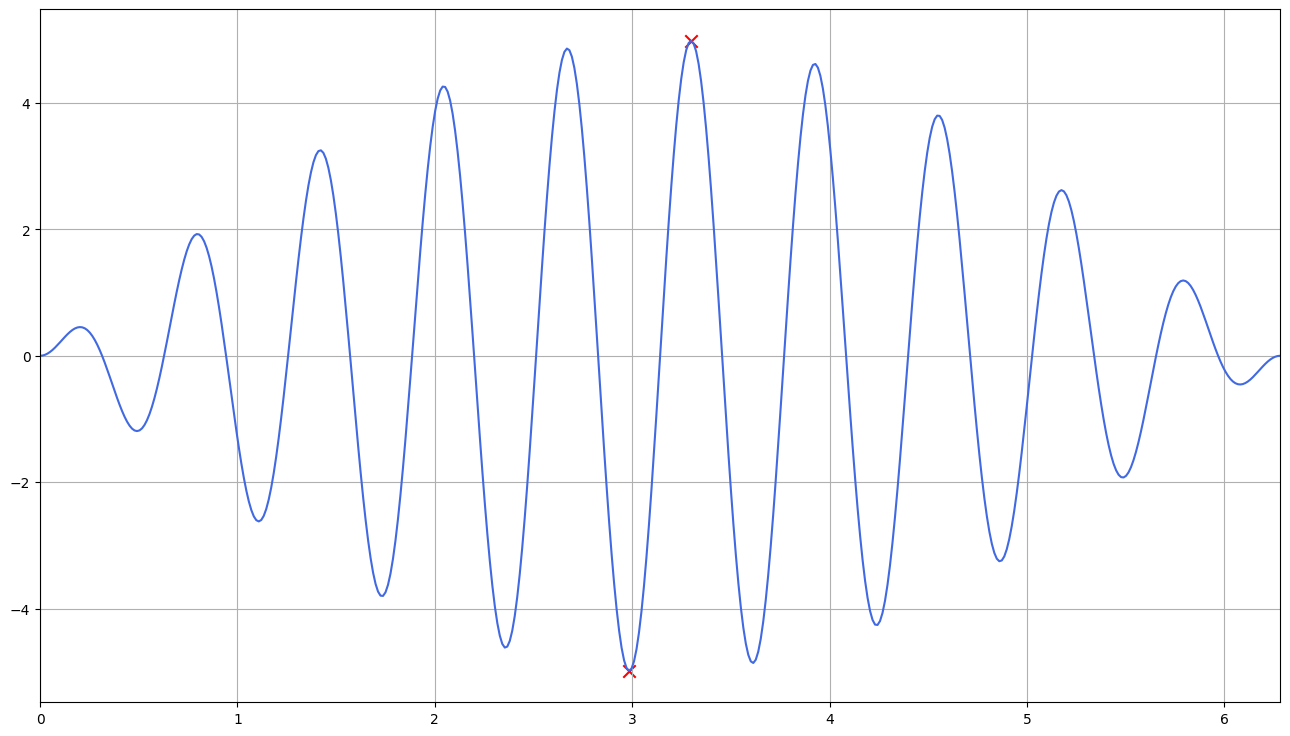

In [32]:
from utils import visualize_1d


time = np.linspace(0, np.pi * 2, 500)
signal_high_freq = np.sin(time * 10)
signal = 5 * np.sin(time * 0.5) * signal_high_freq

extremum = (time[np.argmax(signal)], np.max(signal))
extremum2 = (time[np.argmin(signal)], np.min(signal))
all_points = [extremum, extremum2]
visualize_1d(time, signal, all_points)

Мы также можем искать позицию экстремума и в многомерном массиве, однако, здесь есть небольшой нюанс.

In [33]:
array = np.random.randint(-10, 10, size=(4, 4))
print(f"array:\n{array}", end="\n\n")

position_min = np.argmin(array)
print(f"{position_min = }")

array:
[[ -5  -2  -4  -2]
 [ -7  -3  -8   2]
 [-10   3   6   0]
 [ -1  -3   5   3]]

position_min = 8


В примере выше мы получили одно число вместо ожидаемой позиции минимального элемента в двумерном массиве. Но почему? Все дело в том, что для упрощения поиска, NumPy сначала "вытягивает" многомерный массив в одномерны. Т.е. фактически, в примере выше произошло следующее:

In [34]:
array_flatten = array.flatten()
print(f"array flattened:\n{array_flatten}", end="\n\n")

print(f"elem min: {array_flatten[position_min]}")

array flattened:
[ -5  -2  -4  -2  -7  -3  -8   2 -10   3   6   0  -1  -3   5   3]

elem min: -10


Теперь мы понимаем, как именно была посчитана позиция минимального элемента в случае двумерного массива. Однако от этого легче нам не становится, ведь мы по прежнему не знаем индексы минимума в двумерном массиве. В этом случае мы, конечно, могли бы написать функцию для перевода индекса одномерного массива в индексы колонок и столбцов двумерного массива, которые соответствуют минимальному элементу. Но что делать если мы имеем дело с четырехмерным массивом? А с восьмимерным? Неужели нам придется писать функции перевода для каждого случая?

На самом деле нет, ведь в NumPy все уже давно реализовано:

In [35]:
position_min_2d = np.unravel_index(position_min, shape=array.shape)
print(f"position_min = {position_min_2d}")

position_min = (2, 0)


Стоит иметь в виду описанyю особенность при работе с многомерными массивами и не забывать о функции `unravel_index`.

### Замечание

Большая часть функций, описанных выше, является аналогами соответствующих функций в "чистом" Python, однако, не стоит считать, что они взаимозаменяемы. Во-первых, аналоги из Python будут работать значительно медленнее функций из NumPy в силу причин, которые были рассмотрены на предыдущих семинарах. Во-вторых, функции Python не умеют корректно работать с многомерными массивами, в отличие от функций NumPy. Более того, функции NumPy позволяют настраивать агрегирование, о чем мы поговорим далее.

## Агрегирование по измерениям

Во всех примерах выше мы применяли операции агрегирования к одномерным массивам. Однако, как было сказано в предыдущем абзаце, мы можем применять указанные операции и к многомерным массивам.

In [36]:
array = np.random.randint(-10, 10, size=(3, 4))
print(f"array:\n{array}", end="\n\n")

print(
    f"sum: {np.sum(array)};",
    f"cumulative sum: {np.cumsum(array)};",
    f"max: {np.max(array)};",
    sep="\n",
)

array:
[[-2  6  2 -8]
 [-5  2 -8  8]
 [-5  3  0 -4]]

sum: -11;
cumulative sum: [ -2   4   6  -2  -7  -5 -13  -5 -10  -7  -7 -11];
max: 8;


Как вы видите, в этом случае операция будет применяться ко всему массиву, игнорируя его пространственные данные. Однако, с помощью специального аргумента `axis` вы можете выбирать, для каких именно измерений массива применять ту или иную операцию. Рассмотрим эти возможности на примере функции `sum`, поскольку поведение остальных функций в контексте их применения для конкретных измерений, не будет отличаться.

In [37]:
array = np.random.randint(-10, 10, size=(3, 4))
print(f"array:\n{array}", end="\n\n")

print(
    f"sum whole: {np.sum(array)};",
    f"sum per column: {np.sum(array, axis=0)};",
    f"sum per row: {np.sum(array, axis=1)};",
    sep="\n",
)

array:
[[ -3  -3   9  -7]
 [ -9 -10   3  -4]
 [-10   3  -3   6]]

sum whole: -28;
sum per column: [-22 -10   9  -5];
sum per row: [ -4 -20  -4];


Как вы видите, теперь у нас есть возможность агрегировать данные по определенным измерениям. Обращаем ваше внимание на то, что массив "схлопывается" вдоль указанных измерений, а результирующий массив имеет меньшую размерность, при этом сохраняя свои исходные размеры вдоль оставшихся измерений. При необходимости вы можете сохранить и размерность исходного массива, однако размер вдоль агрегированного измерения все равно будет "схлопнут".

In [43]:
print(f"sum per column: {np.sum(array, axis=0, keepdims=True)};")

sum per column: [[-22 -10   9  -5]];


Сохранение размерности бывает очень полезным, особенно при использовании результирующего массива в векторизованных операциях с применением трансляции.

Помимо указания измерения в виде целых неотрицательных чисел, вы можете задавать измерения агрегации с помощью кортежей, в этом случае агрегация будет происходить вдоль указанных измерений. Также вы можете использовать отрицательные целые числа. Например, `-1` - в этом случае агрегация будет осуществлена по последнему измерению массива.

In [46]:
array = np.random.randint(-10, 10, size=(2, 3, 2))
print(f"array:\n{array};", end="\n\n")

print(
    f"axis negative:\n{np.sum(array, axis=-2)}",
    f"axis tuple:\n{np.sum(array, axis=(0, 2))}",
    f"axis tuple keepdim:\n{np.sum(array, axis=(0, 2), keepdims=True)}",
    sep="\n\n",
)

array:
[[[ 7  2]
  [ 8  3]
  [ 5  2]]

 [[ 6 -3]
  [ 1  8]
  [ 0  7]]];

axis negative:
[[20  7]
 [ 7 12]]

axis tuple:
[12 20 14]

axis tuple keepdim:
[[[12]
  [20]
  [14]]]


## Сортировки

### Сортировка

Из курса по алгоритмам и структурам данных вам должна быть известна важность алгоритмов сортировки. Зачастую сортировка является полезной как сама по себе, так и как шаг в более сложных алгоритмах. Именно поэтому в NumPy реализована возможность сортировки массивов. Подобно "чистому" Python функция сортировки существует в двух вариантах: как отдельная функция, которая создает новый массив с отсортированными значениями, и как метод массива, который осуществляет сортировку на месте.

In [66]:
array = np.random.randint(-10, 10, size=10)
print(f"array original:\n{array}", end="\n\n")

array_sorted = np.sort(array)
print(
    f"array sorted:\n{array_sorted}",
    f"array_sorted is array: {array_sorted is array}",
    sep="\n",
    end="\n\n"
)

array.sort()
print(
    f"array2 sorted:\n{array}",
    f"array2 is array: {array is array}",
    sep="\n",
    end="\n\n"
)

array original:
[-3 -5 -1 -2 -4 -1 -9  2  7 -5]

array sorted:
[-9 -5 -5 -4 -3 -2 -1 -1  2  7]
array_sorted is array: False

array2 sorted:
[-9 -5 -5 -4 -3 -2 -1 -1  2  7]
array2 is array: True



В отличие от функций Python данные функции имеют ряд интересных особенностей, помимо разницы в производительности. С одной из таких особенностей мы уже знакомы: возможность применения операции вдоль определенного измерения.

In [67]:
array = np.random.randint(-10, 10, size=(3, 4))
print(f"array:\n{array}", end="\n\n")

print(
    f"default sort:\n{np.sort(array)}",
    f"per row sort:\n{np.sort(array, axis=-1)}",
    f"per column sort:\n{np.sort(array, axis=0, kind='quicksort')}",
    sep="\n\n",
)

array:
[[ 4 -4 -3 -6]
 [-2  1 -7  1]
 [ 3 -1  5 -3]]

default sort:
[[-6 -4 -3  4]
 [-7 -2  1  1]
 [-3 -1  3  5]]

per row sort:
[[-6 -4 -3  4]
 [-7 -2  1  1]
 [-3 -1  3  5]]

per column sort:
[[-2 -4 -7 -6]
 [ 3 -1 -3 -3]
 [ 4  1  5  1]]


Следующая интересная особенность функций сортировки - возможность выбора алгоритма сортировки. Если в Python функции сортировки использовали *timsort*, то в NumPy вы можете выбрать подходящий для конкретной задачи алгоритм, передав в функцию параметр `kind`. На выбор доступны следующие варианты: *quicksort*, *mergesort*, *heapsort*, *stable*.

### Сортировка индексов

Помимо обычных сортировок в NumPy реализована возможность вычисления сортировки по аргументу. Т.е. существуют специальные функции, которые вычисляет не отсортированный массив, а массив индексов. Индексы расположены так, как соответствующие им элементы должны были бы располагаться в отсортированном массиве, при этом сам массив изменений не претерпевает.

In [68]:
array = np.random.randint(-10, 10, size=10)
print(f"array:\n{array}", end="\n\n")

indices = np.argsort(array)
print(
    f"array:\n{array}",
    f"indices:\n{indices}",
    f"array sorted:\n{array[indices]}",
    sep="\n",
)

array:
[ 3 -4 -3 -5  9  3 -2  1  0 -4]

array:
[ 3 -4 -3 -5  9  3 -2  1  0 -4]
indices:
[3 1 9 2 6 8 7 0 5 4]
array sorted:
[-5 -4 -4 -3 -2  0  1  3  3  9]


Данная функция также может быть использована вдоль определенных измерений массива.

In [84]:
array = np.random.randint(-10, 10, size=(3, 4))
print(f"array:\n{array}", end="\n\n")

print(
    f"default sort:\n{np.argsort(array)}",
    f"per row sort:\n{np.argsort(array, axis=-1)}",
    f"per column sort:\n{np.argsort(array, axis=0)}",
    sep="\n"
)

array:
[[ 5 -6  2  6]
 [ 9  8 -9  1]
 [-3 -8 -2  3]]

default sort:
[[1 2 0 3]
 [2 3 1 0]
 [1 0 2 3]]
per row sort:
[[1 2 0 3]
 [2 3 1 0]
 [1 0 2 3]]
per column sort:
[[2 2 1 1]
 [0 0 2 2]
 [1 1 0 0]]


In [124]:
array = np.random.randint(-10, 10, size=(3,4))
print(f"array:\n{array}", end="\n\n")

print(np.argsort(array), end="\n\n")    # сортировка в порядке не возрастания
print(np.argsort(array)[:, ::-1])

array:
[[-8  0  8 -8]
 [ 4 -1  6 -1]
 [ 7  2  7  7]]

[[0 3 1 2]
 [1 3 0 2]
 [1 0 2 3]]

[[2 1 3 0]
 [2 0 3 1]
 [3 2 0 1]]


Обратите ваше внимание, что сортировка осуществляется в порядке не убывания, а аргумент `reverse` отсутствует. Подумайте о возможных способах реализации сортировки в порядке не возрастания с помощью операций NumPy.

## Практика 1. МНК

Необходимо реализовать функцию для нахождения коэффициентов линейной функции с помощью МНК.

*Входные данные*:
- `abscissa` - np.ndarray, абсциссы точек;
- `ordinates` - np.ndarray, ординаты точек;

*Выходные данные*:
- Кортеж (`tuple`) двух чисел с плавающей точкой: коэффициент наклона `a` и смещение `b` функции $y = ax + b$;

*Сторонние эффекты*:
- Если количества элементов во входных массивах `abscissa` и `ordinates` отличаются, необходимо возбудить исключение `ShapeMismatchError`.

*Замечания*:
- Гарантируется, что на вход подаются непустые одномерные массивы чисел с плавающей точкой;
- Гарантируется, что входные массивы не описывают функции $y = const$ и $x = const$;
- Формулы для нахождения коэффициентов линейной функции $y = ax + b$ с помощью МНК:

    $$ a = \frac{<xy> - <x><y>}{<x^2> - <x>^2} $$
    
    $$ b = <y> - a<x> $$

    Нотация `<...>` используется для обозначения среднего значения.

**Решение**:

In [3]:
from numbers import Real

from utils import visualize_lsm

In [4]:
class ShapeMismatchError(Exception):
    pass

In [10]:
def get_lsm_coefficients(
    x: np.ndarray,
    y: np.ndarray,
) -> tuple[Real, Real]:
    m = np.mean

    a = (m(x * y) - m(x) * m(y)) / (m(x**2) - m(x)**2)
    b = m(y) - a * m(x)

    return a, b

**Проверка**:

In [11]:
abscissa = np.linspace(0, 10, 100)
ordinates_experiment = abscissa * 5 + 3
ordinates_experiment += 2 * np.random.normal(size=abscissa.size)

incline, shift = get_lsm_coefficients(abscissa, ordinates_experiment)
print(
    f"computed incline: {incline:.2f};",
    f"computed shift: {shift:.2f};",
    sep="\n",
)

computed incline: 4.95;
computed shift: 2.97;


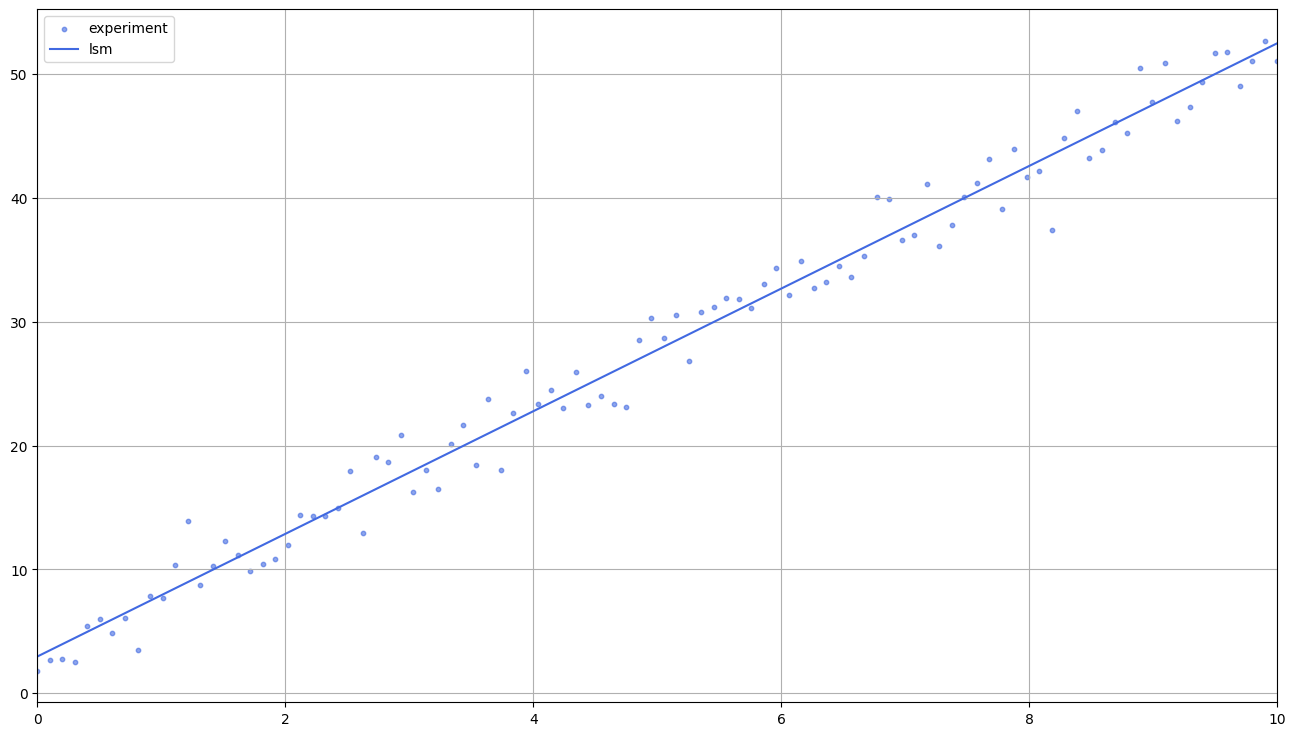

In [12]:
visualize_lsm(
    abscissa=abscissa,
    ordinates_experiment=ordinates_experiment,
    ordinates_computed=incline * abscissa + shift,
)